In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python/Mall_Customers.csv


TASK 2: CUSTOMER SEGMENTATION
Dataset shape: (200, 5)
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


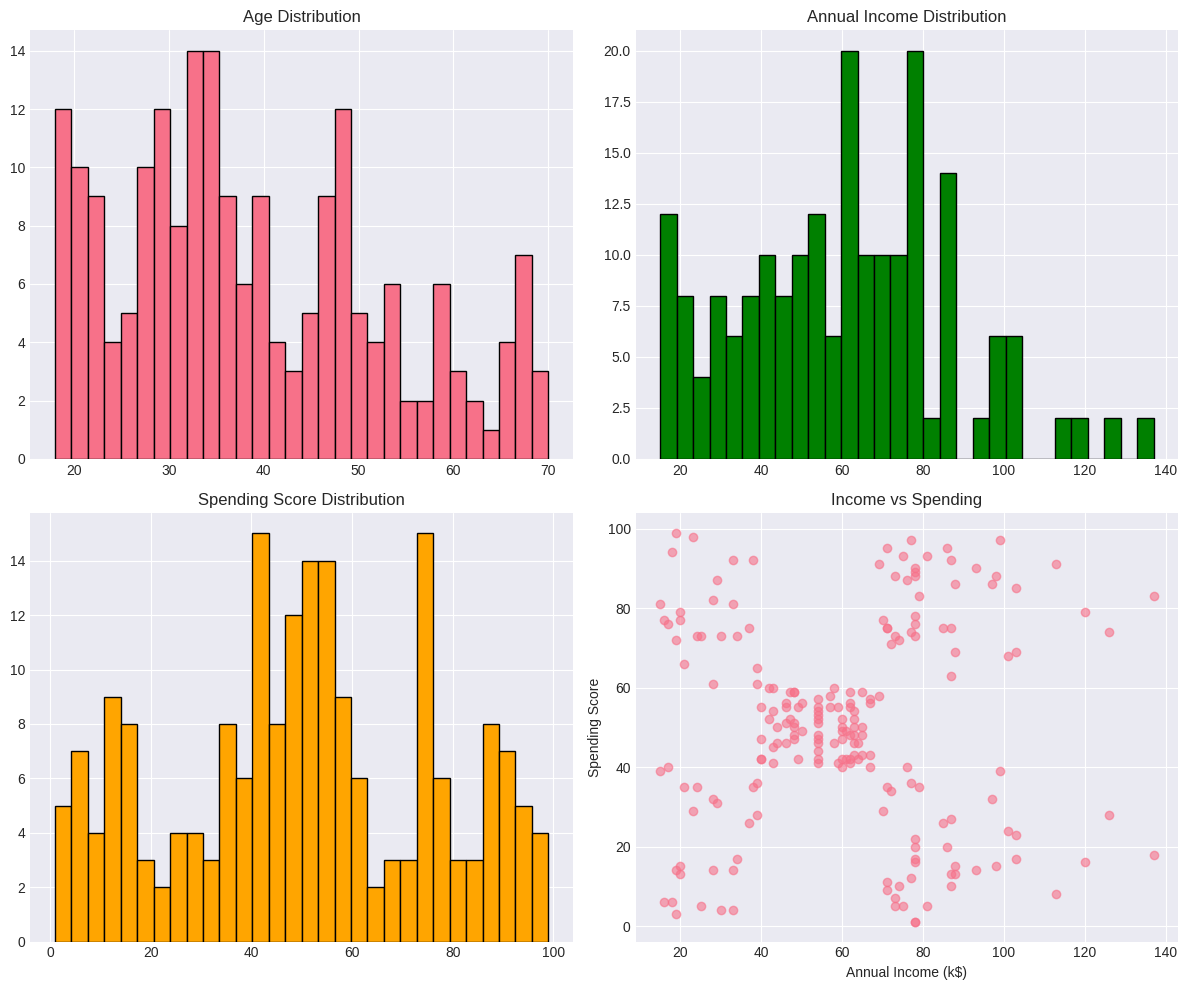

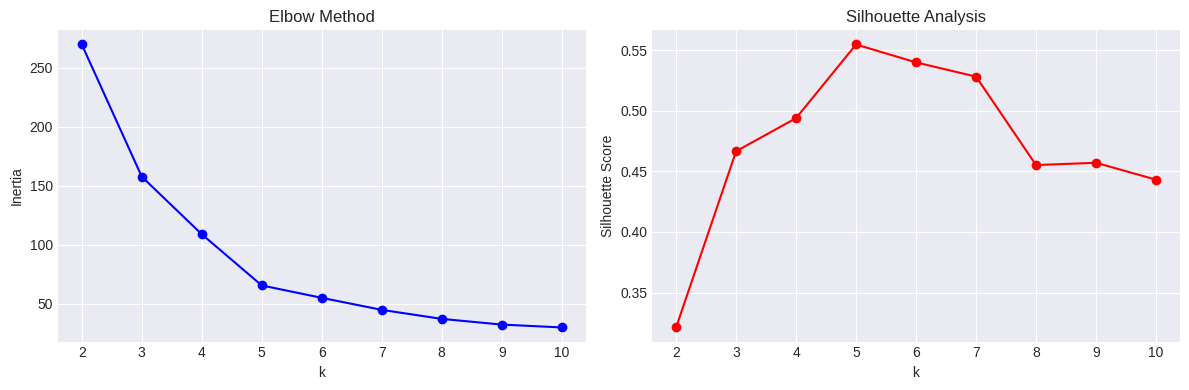


Optimal clusters: 5
Silhouette Score: 0.5547


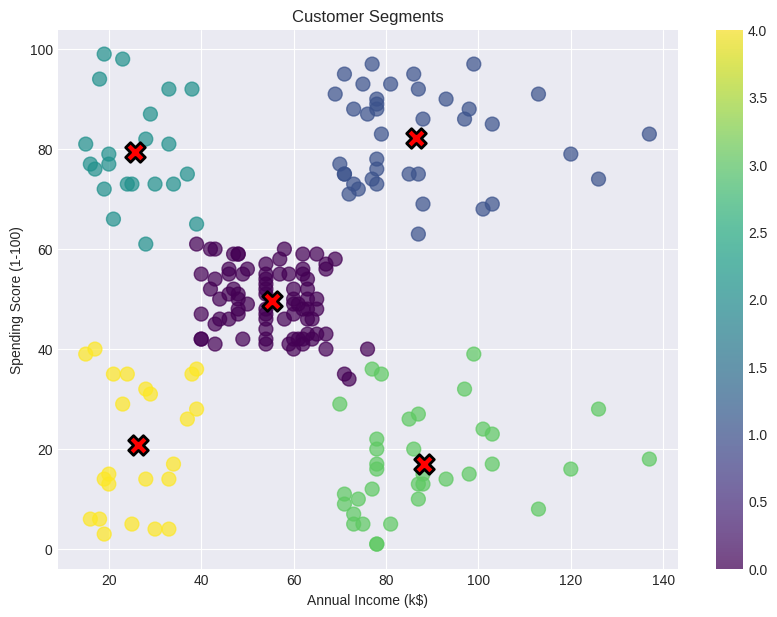

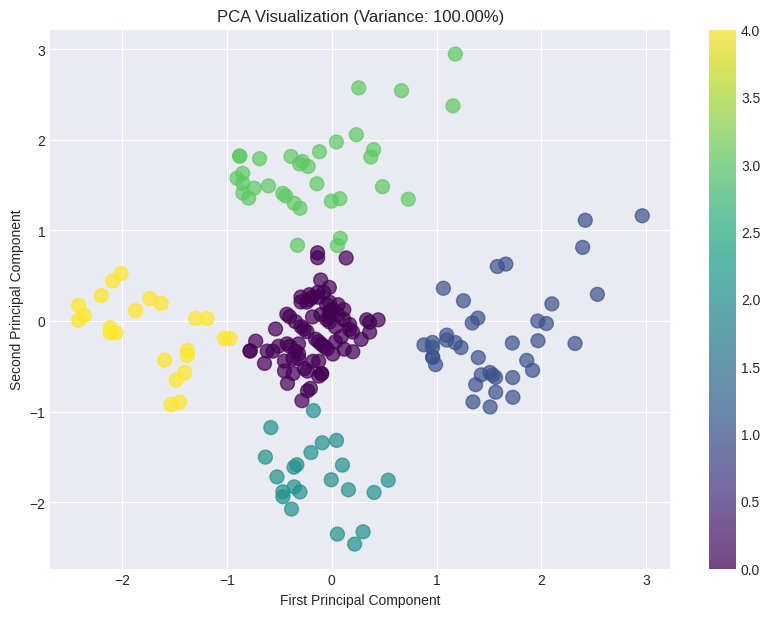


📊 CLUSTER PROFILES:
         Size    Age  Annual Income (k$)  Spending Score (1-100)  Gender
Cluster                                                                 
0          81  42.72               55.30                   49.52  Female
1          39  32.69               86.54                   82.13  Female
2          22  25.27               25.73                   79.36  Female
3          35  41.11               88.20                   17.11    Male
4          23  45.22               26.30                   20.91  Female

💡 MARKETING STRATEGIES:
Cluster 0 (81 customers, 40.5%): 💰 HIGH INCOME, MEDIUM SPENDING → Premium loyalty program
Cluster 1 (39 customers, 19.5%): 📉 LOW INCOME, LOW SPENDING → Discount campaigns & bundles
Cluster 2 (22 customers, 11.0%): ⭐ AVERAGE INCOME, AVERAGE SPENDING → Standard marketing
Cluster 3 (35 customers, 17.5%): 💎 HIGH INCOME, HIGH SPENDING → VIP experiences & exclusive products
Cluster 4 (23 customers, 11.5%): 🛍️ LOW INCOME, HIGH SPENDING → Installm

In [2]:
# %% [markdown]
# # 🛍️ Task 2: Customer Segmentation
# ## DevelopersHub Corporation - Data Science Internship

# %% [code]
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("="*60)
print("TASK 2: CUSTOMER SEGMENTATION")
print("="*60)

# %% [code]
# Load data
# Option 1: From Kaggle dataset
df = pd.read_csv('/kaggle/input/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python/Mall_Customers.csv')

# Option 2: Direct URL (uncomment if needed)
# url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"
# df = pd.read_csv(url)

print(f"Dataset shape: {df.shape}")
print(df.head())

# %% [code]
# EDA
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

df['Age'].hist(bins=30, ax=axes[0,0], edgecolor='black')
axes[0,0].set_title('Age Distribution')

df['Annual Income (k$)'].hist(bins=30, ax=axes[0,1], edgecolor='black', color='green')
axes[0,1].set_title('Annual Income Distribution')

df['Spending Score (1-100)'].hist(bins=30, ax=axes[1,0], edgecolor='black', color='orange')
axes[1,0].set_title('Spending Score Distribution')

axes[1,1].scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'], alpha=0.6)
axes[1,1].set_xlabel('Annual Income (k$)')
axes[1,1].set_ylabel('Spending Score')
axes[1,1].set_title('Income vs Spending')

plt.tight_layout()
plt.savefig('/kaggle/working/eda_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

# %% [code]
# Feature selection and scaling
features = ['Annual Income (k$)', 'Spending Score (1-100)']
X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Find optimal k
inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

# Plot elbow
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(K_range, inertias, 'bo-')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')

axes[1].plot(K_range, silhouette_scores, 'ro-')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Analysis')

plt.tight_layout()
plt.savefig('/kaggle/working/elbow_method.png', dpi=100, bbox_inches='tight')
plt.show()

# Optimal k = 5
optimal_k = 5
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

print(f"\nOptimal clusters: {optimal_k}")
print(f"Silhouette Score: {silhouette_score(X_scaled, df['Cluster']):.4f}")

# %% [code]
# Cluster visualization
plt.figure(figsize=(10, 7))
scatter = plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'], 
                      c=df['Cluster'], cmap='viridis', s=100, alpha=0.7)
plt.scatter(kmeans.cluster_centers_[:, 0] * scaler.scale_[0] + scaler.mean_[0],
           kmeans.cluster_centers_[:, 1] * scaler.scale_[1] + scaler.mean_[1],
           c='red', marker='X', s=200, edgecolors='black', linewidths=2)
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Customer Segments')
plt.colorbar(scatter)
plt.savefig('/kaggle/working/clusters.png', dpi=100, bbox_inches='tight')
plt.show()

# %% [code]
# PCA Visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['Cluster'], cmap='viridis', s=100, alpha=0.7)
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title(f'PCA Visualization (Variance: {pca.explained_variance_ratio_.sum():.2%})')
plt.colorbar(scatter)
plt.savefig('/kaggle/working/cluster_pca.png', dpi=100, bbox_inches='tight')
plt.show()

# %% [code]
# Cluster profiles
cluster_profiles = df.groupby('Cluster').agg({
    'CustomerID': 'count',
    'Age': 'mean',
    'Annual Income (k$)': 'mean',
    'Spending Score (1-100)': 'mean',
    'Gender': lambda x: x.mode()[0]
}).rename(columns={'CustomerID': 'Size'})

print("\n📊 CLUSTER PROFILES:")
print(cluster_profiles.round(2))

# Marketing strategies
strategies = {
    0: "💰 HIGH INCOME, MEDIUM SPENDING → Premium loyalty program",
    1: "📉 LOW INCOME, LOW SPENDING → Discount campaigns & bundles",
    2: "⭐ AVERAGE INCOME, AVERAGE SPENDING → Standard marketing",
    3: "💎 HIGH INCOME, HIGH SPENDING → VIP experiences & exclusive products",
    4: "🛍️ LOW INCOME, HIGH SPENDING → Installment payment options"
}

print("\n💡 MARKETING STRATEGIES:")
for cluster, strategy in strategies.items():
    size = cluster_profiles.loc[cluster, 'Size']
    pct = size/len(df)*100
    print(f"Cluster {cluster} ({size} customers, {pct:.1f}%): {strategy}")

# Save results
cluster_profiles.to_csv('/kaggle/working/cluster_profiles.csv')

print("\n✅ Task 2 Completed!")